To use this script, label the grains interiors with magenta in image j (or you can change the color threshold to something other than magenta, imagej will tell you the value), and the boundaries with white. Anything unlabelled gets mapped to background

There are two remapping modes, selectable via `mapping_mode` in the cell below:

- `"three_class"`: background (0) / interior (1) / boundary (2). Interior is taken from `grain_interior` (magenta), boundary from `grain_bound` (white = 255), everything else is background. This is the original behaviour.
- `"boundary_interior"`: only two classes. Pixels equal to 255 become boundary (2), and **everything else** becomes interior (1). There is no background class in this mode.

uint8 4 252
[  4  11  12  14  17  19  20  21  22  23  24  25  26  28  29  30  31  32
  33  34  35  37  38  39  40  41  42  43  44  46  47  48  49  50  51  52
  53  55  56  57  58  59  60  61  62  64  65  66  67  68  69  70  71  73
  74  75  76  77  78  79  80  82  83  84  85  86  87  88  89  91  92  93
  94  95  96  97  98 100 101 102 103 104 105 106 107 109 110 111 112 113
 114 115 116 118 119 120 121 122 123 124 125 127 128 129 130 131 132 133
 134 136 137 138 139 140 141 142 143 145 146 147 148 149 150 151 152 154
 155 156 157 158 159 160 161 163 164 165 166 167 168 169 170 172 173 174
 175 176 177 178 179 181 182 183 184 185 186 187 188 190 191 192 193 194
 197 200 201 202 206 212 214 215 251 252]
Most frequent pixel values:
Value 105: 219475 pixels
Value 252: 51704 pixels
Value 71: 26572 pixels
Value 62: 23452 pixels
Value 80: 19481 pixels
Value 69: 13528 pixels
Value 70: 13482 pixels
Value 68: 13350 pixels
Value 67: 13329 pixels
Value 66: 13266 pixels


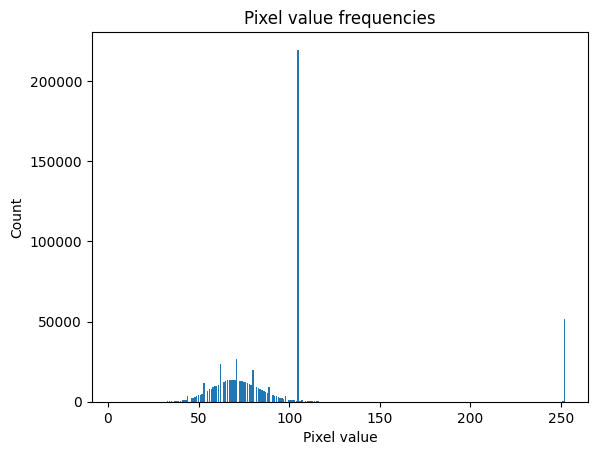

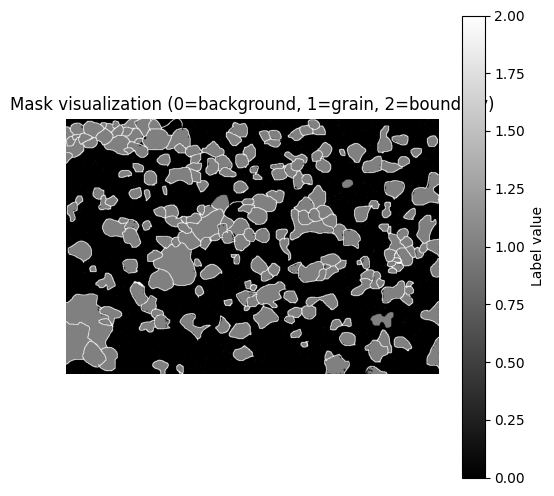

Grain interior pixels (1): 219475
Grain boundary pixels (2): 51704
Mask remapped (mode: three_class)


In [9]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

name="annotations/annotated_cropped_Wilson180_0.25__surface1_05.tif"
#name="/Users/Alexander/Repositories/segmenteverygrain/annotations/annotated_cropped_prac7_etched_020.tif"

# Select the remapping mode:
#   "three_class"       -> background (0) / interior (1, from grain_interior) / boundary (2, from grain_bound)
#   "boundary_interior" -> boundary (2) where pixel == 255, interior (1) everywhere else (no background)
mapping_mode = "three_class"

# Load grayscale image
img = cv2.imread(name, cv2.IMREAD_GRAYSCALE)
grain_bound=252 #don't agree with imagej but seem to work
grain_interior=105
print(img.dtype, img.min(), img.max())
print(np.unique(img))

unique, counts = np.unique(img, return_counts=True)

# Combine and sort by count descending
value_counts = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

print("Most frequent pixel values:")
for val, cnt in value_counts[:10]:
    print(f"Value {val}: {cnt} pixels")

plt.bar([v for v, c in value_counts], [c for v, c in value_counts]) #plot values, for debugging color issue
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Pixel value frequencies")
plt.show()

# Apply thresholding / labeling
if mapping_mode == "three_class":
    # Everything starts as background (0)
    labels = np.zeros_like(img, dtype=np.uint8)
    labels[img == grain_interior] = 1
    labels[img == grain_bound] = 2
elif mapping_mode == "boundary_interior":
    # Everything starts as interior (1), only 255 becomes boundary (2)
    labels = np.ones_like(img, dtype=np.uint8)
    labels[img == 252] = 2
else:
    raise ValueError(f"Unknown mapping_mode: {mapping_mode!r}")

# Build output filename: <originalname>_mask.tif
directory, filename = os.path.split(name)
base, ext = os.path.splitext(filename)

output_filename = f"{base}_mask{ext}"
output_path = os.path.join(directory, output_filename)

# Save result
cv2.imwrite(output_path, labels)


# Grayscale visualization (1–2 mapped properly)
plt.figure(figsize=(6, 6))
plt.imshow(labels, cmap="gray", vmin=0, vmax=2)
plt.colorbar(label="Label value")
if mapping_mode == "three_class":
    plt.title("Mask visualization (0=background, 1=grain, 2=boundary)")
else:
    plt.title("Mask visualization (1=grain interior, 2=boundary)")
plt.axis("off")
plt.show()

num_grain_pixels = np.sum(labels == 1)
num_boundary_pixels = np.sum(labels == 2)

print(f"Grain interior pixels (1): {num_grain_pixels}")
print(f"Grain boundary pixels (2): {num_boundary_pixels}")

print(f"Mask remapped (mode: {mapping_mode})")
